In [1]:
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import skimage.io as io
from glob import glob
import os

# Example iamge

In [5]:
filename="/home/kn445/rds/hpc-work/ml-oct/models/U-Net/without_noise/eval_outputs/false_NORMAL_png/AMD/1_out.png"
original_filename = '/home/kn445/rds/hpc-work/ml-oct/datasets/clas_dataset/combined3_split_rgb_jpeg_predicted_NORMAL_2png/AMD/1.png'
filename_jpeg = "/home/kn445/rds/hpc-work/ml-oct/models/U-Net/without_noise/eval_outputs/false_NORMAL/AMD/1_out.jpeg"
original_filename_jpeg = '/home/kn445/rds/hpc-work/ml-oct/datasets/clas_dataset/kaggle_output/combined3_split_rgb_jpeg_predicted_NORMAL/AMD/1.jpeg'
mask = io.imread(filename)
image_ori = io.imread(original_filename)
mask_jpeg = io.imread(filename_jpeg)
image_ori_jpeg = io.imread(original_filename_jpeg)

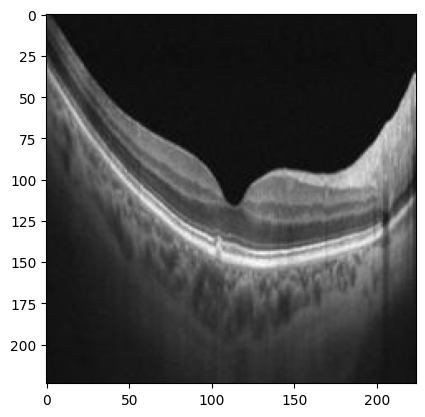

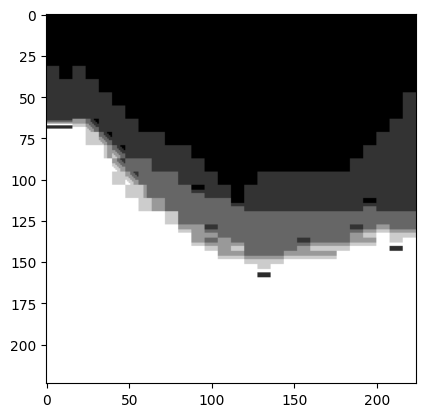

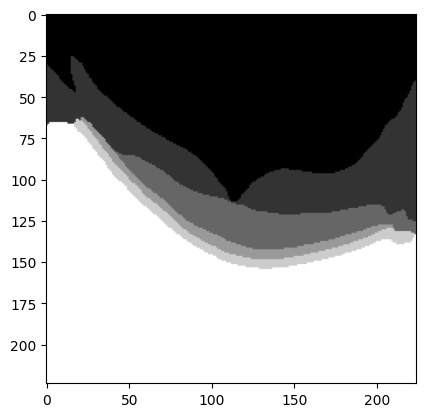

In [7]:
# visualise the image
# plt.subplot(121)
plt.imshow(image_ori_jpeg)
plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/original_jpeg.png')
plt.show()
# plt.title('original')
# plt.subplot(122)
plt.imshow(mask_jpeg*50, cmap='gray')
plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/mask_jpeg.png')
plt.show()
plt.imshow(mask*50, cmap='gray')
plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/mask_png.png')
plt.show()
# plt.title('predicted')

In [4]:
# test = np.array([[1,1],[2,2],[3,3],[4,4],[5,5]])
# print(test.shape)
# # test.shape[0] is the number of rows

In [5]:
def calc_thickness(pred_mask):
  total = pred_mask.shape[0]
  ones = np.count_nonzero(pred_mask==1, axis=0)
  twos = np.count_nonzero(pred_mask==2, axis=0)
  threes = np.count_nonzero(pred_mask==3, axis=0)
  fours = np.count_nonzero(pred_mask==4, axis=0)
  fives = np.count_nonzero(pred_mask==5, axis=0)
  zeros = total - ones - twos - threes - fours - fives

  return np.array([zeros, ones, twos, threes, fours, fives])

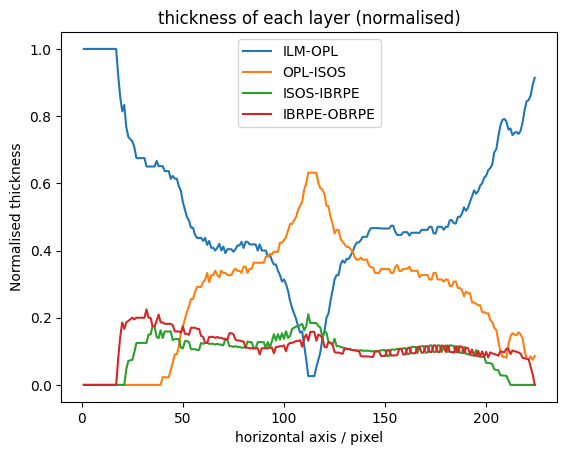

In [6]:
thickness = calc_thickness(mask)

# print(thickness[0], len(thickness[0]))

x = np.arange(1,mask.shape[0]+1)

# print(len(ones))
# print(len(horizontal))

# # Thickness of each layer by pixels (raw data, no normalisation, no rotation)
# plt.plot(x, thickness[1], label='ILM-OPL')
# plt.plot(x, thickness[2], label='OPL-ISOS')
# plt.plot(x, thickness[3], label='ISOS-IBRPE')
# plt.plot(x, thickness[4], label='IBRPE-OBRPE')
# plt.title('thickness of each layer')
# plt.xlabel('horizontal axis / pixel')
# plt.ylabel('Number of pixels')
# plt.legend()
# plt.show()

# print(thickness[1], '\n', thickness[2])
# print(thickness[1]+thickness[2])
total = thickness[1] + thickness[2] + thickness[3] + thickness[4]
# print(total)
# print(len(total))

# Thickness of each layer by pixels (normalised by the thickness of ILM-OBRPE in each column)
# dividing point-wise
plt.plot(x, thickness[1]/total, label='ILM-OPL')
plt.plot(x, thickness[2]/total, label='OPL-ISOS')
plt.plot(x, thickness[3]/total, label='ISOS-IBRPE')
plt.plot(x, thickness[4]/total, label='IBRPE-OBRPE')
plt.title('thickness of each layer (normalised)')
plt.xlabel('horizontal axis / pixel')
plt.ylabel('Normalised thickness')
plt.legend()
plt.show()

# Calculating layer thickness distribution

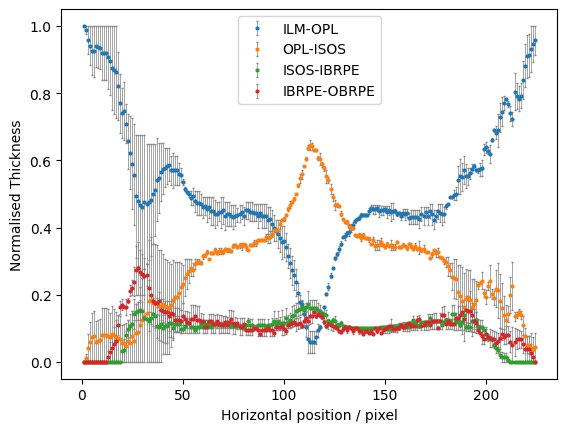

AMD 2


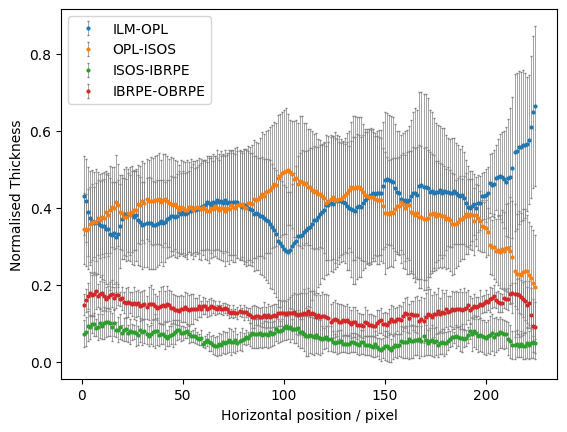

CNV 6


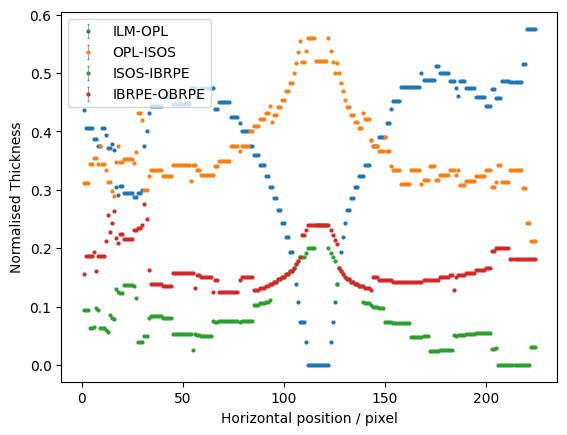

CSR 1


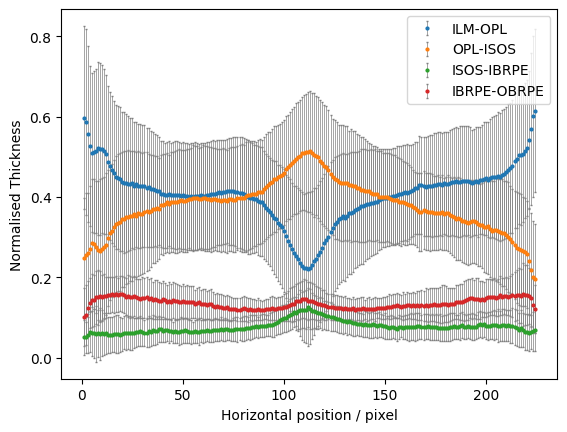

DME 41


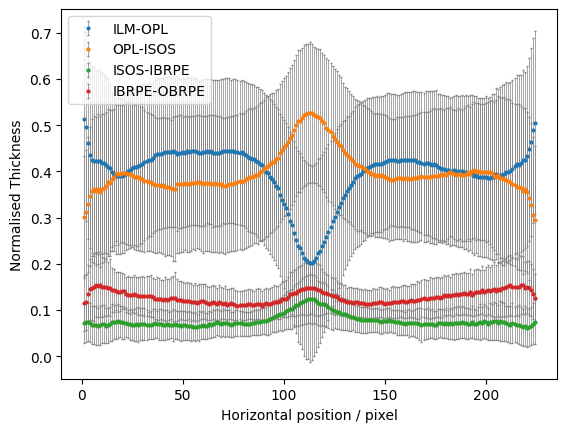

DRUSEN 45


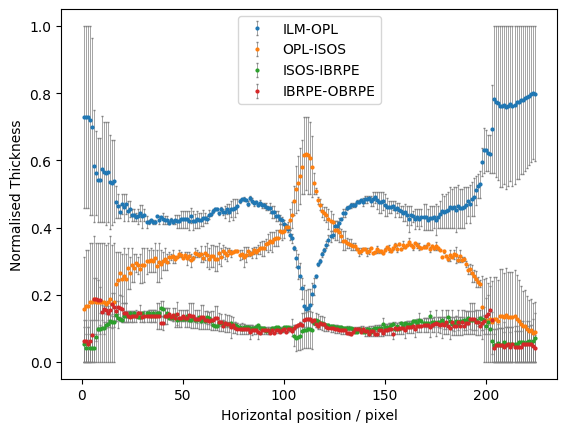

ERM 2


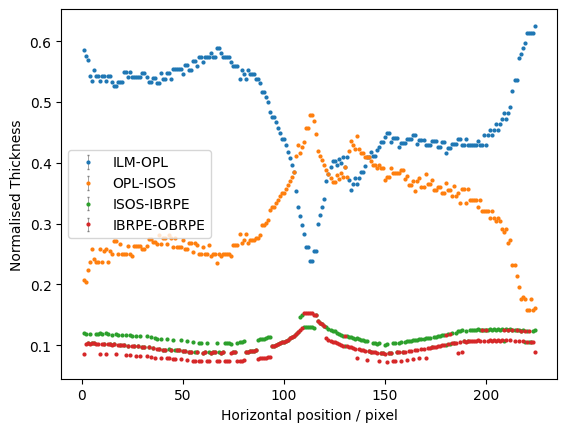

RAO 1


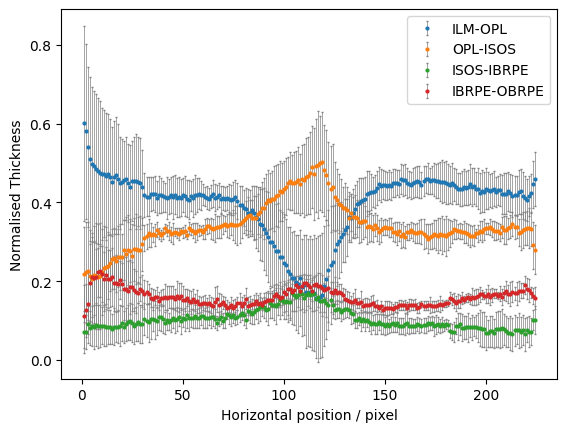

VID 6


In [8]:
# https://earthdatascience.org/courses/intro-to-earth-data-science/python-code-fundamentals/work-with-files-directories-paths-in-python/os-glob-manipulate-file-paths/
folder_path= "/home/kn445/rds/hpc-work/ml-oct/models/U-Net/without_noise/eval_outputs/false_NORMAL_png/"
classes = ['AMD', 'CNV', 'CSR', 'DME', 'DRUSEN','ERM', 'RAO', 'VID']
x = np.arange(1,mask.shape[0]+1)

for c in classes:
   imgs_path = glob('{}{}/*.png'.format(folder_path,c), recursive=True)

   normalised_thickness_list = []
   # print(imgs_path)

   for img in imgs_path:
      image = io.imread(img)
      thickness = calc_thickness(image)
      total = thickness[1] + thickness[2] + thickness[3] + thickness[4]
      normalised_thickness_list.append([thickness[1]/total, thickness[2]/total, thickness[3]/total, thickness[4]/total])

   normalised_thickness_tensor = np.array(normalised_thickness_list)
   # print(normalised_thickness_tensor.shape)
   mean = np.mean(normalised_thickness_tensor, axis=0)
   std = np.std(normalised_thickness_tensor, axis=0)
   # print(mean.shape, std.shape)

   plt.errorbar(x, mean[0], yerr=std[0], label='ILM-OPL', capsize=1, ecolor='gray', marker= 'o', markersize=2, linestyle='None', linewidth=0.5)
   plt.errorbar(x, mean[1], yerr=std[1], label='OPL-ISOS', capsize=1, ecolor='gray', marker= 'o', markersize=2, linestyle='None', linewidth=0.5)
   plt.errorbar(x, mean[2], yerr=std[2], label='ISOS-IBRPE', capsize=1, ecolor='gray', marker= 'o', markersize=2, linestyle='None', linewidth=0.5)
   plt.errorbar(x, mean[3], yerr=std[3], label='IBRPE-OBRPE', capsize=1, ecolor='gray', marker= 'o', markersize=2, linestyle='None', linewidth=0.5)
   plt.xlabel('Horizontal position / pixel')
   plt.ylabel('Normalised Thickness')
   plt.legend()
   plt.savefig('/home/kn445/rds/hpc-work/ml-oct/figures/{}_layer_thickness.png'.format(c))
   plt.show()
   print(c, len(imgs_path))

   # plt.plot(x, mean[0], label='ILM-OPL')
   # plt.plot(x, mean[1], label='OPL-ISOS')
   # plt.plot(x, mean[2], label='ISOS-IBRPE')
   # plt.plot(x, mean[3], label='IBRPE-OBRPE')
   # plt.xlabel('Horizontal position / pixel')
   # plt.ylabel('Normalised Thickness')
   # plt.legend()
   # plt.show()

